<a href="https://colab.research.google.com/github/CharalapML/ColabCode/blob/main/ShortFill_Copy_of_Galileo's_Wave_Interactive_Pendulum_A02_z_dimension_TimeDelayTest2_Variable_length_and_g.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Basic Calculation of periodicty of a Simple Pendulum




$\large T = 2\pi$ $ \large\sqrt{L/g}$

where L= length of the pendulum and
g = the acceleration ( here it is gravity )




Position  on 1D path

Parabola :   $x =(\theta)$ and $y= \theta$

Simple Pendulum: $x = lsin(\theta)$ and $y = -lcos(\theta)$, where $l$ = length of pendulum

Kinetic energy:  $T = \frac{1}{2}m ({\dot x}^2 + {\dot y}^2)$ , where $\large\dot x = \frac{dx}{dt}  $  and $\large\dot y = \frac{dy}{dt}  $

Potential Energy: $V = mgy$

The Lagrangian: $L ({d\theta},{d\dot \theta}, {t)}  = T - V$

Lagranges Eqn:  $\large\frac{dL}{d\theta} - \frac{d}{dt}\frac{dL}{d\dot \theta} = 0$ , where $\large\dot\theta = \frac{d\theta}{dt}  $

So

$\large\frac{dL}{d\theta} = \frac{d}{dt}\frac{dL}{d\dot \theta} $     $i.e.   \large lhs = rhs $

In [1]:
pip install ipyvolume

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.1 MB/s eta 0:00:00


In [2]:
import numpy as np
from math import exp

import sympy as sp
from sympy.utilities import lambdify
from sympy.solvers import solve
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import PillowWriter
from IPython.display import HTML

import mpl_toolkits.mplot3d.axes3d as p3
import ipyvolume as ipv

import time
import datetime

In [3]:
InitialTime = datetime.datetime.now()
print (InitialTime)


2026-02-25 13:42:47.469713


In [4]:
class Pendulum:
  def __init__(self, l, t, theta0, v0):  #theta0 = starting angle, v0 = starting velocity
    self.l = l
    self.t = t
    self.conds = [theta0, v0]

  def SolvePendulum(self):
    # m = mass, g = gravity (=9.81m/s), l = length of pendulum, t = time
    m,g,l,t = sp.symbols('m g l t')
    theta = sp.Function('theta')(t)
    #display(theta)
    dtheta  = theta.diff(t)   # velocity
    ddtheta = dtheta.diff(t)  # acceleration

    x,y = l*sp.sin(theta), -l*sp.cos(theta)

    T = sp.Rational(1,2) * m * (x.diff(t)**2 + y.diff(t)**2)
    V = m*g*y
    L = T-V

    #display(L.simplify())

    lhs = L.diff(theta)
    rhs = sp.diff(L.diff(dtheta), t)

    eq = rhs - lhs
    #display(eq)
    eq = sp.solve(eq, ddtheta)[0]
    #display(eq.simplify())

    dthetadt_num =sp.lambdify(dtheta, dtheta)
    dudt_num  = sp.lambdify((g, l, theta), eq)

    x_num, y_num = sp.lambdify((l, theta), x), sp.lambdify((l,theta), y)
    # x_num, y_num are 𝑙𝑠𝑖𝑛(𝜃) and 𝑦= -𝑙𝑐𝑜𝑠(𝜃)

    del m,g,l,t

    l = self.l
    t = self.t
    g = 9.81*(l/1.5)
    conds =self.conds

    def dXdt(X,t,g,l):
      theta_num, u_num = X

      return [dthetadt_num(u_num),
              dudt_num(g,l,theta_num)]

    sol = odeint(dXdt, t=t, y0=conds, args=(g,l))
    angle = sol.T[0] # ie theta
    velocity = sol.T[1]

    return x_num(l,angle), y_num(l,angle), sol  # sol.T,

  def SolvePendulumR(self):
      # m = mass, g = gravity (=9.81m/s), l = length of pendulum, t = time
      m,g,l,t = sp.symbols('m g l t')
      theta = sp.Function('theta')(t)
      #display(theta)
      dtheta  = theta.diff(t)   # velocity
      ddtheta = dtheta.diff(t)  # acceleration

      x,y = l*sp.sin(theta), -l*sp.cos(theta)

      T = sp.Rational(1,2) * m * (x.diff(t)**2 + y.diff(t)**2)
      V = m*g*y
      L = T-V

      #display(L.simplify())

      lhs = L.diff(theta)
      rhs = sp.diff(L.diff(dtheta), t)

      eq = rhs - lhs
      #display(eq)
      eq = sp.solve(eq, ddtheta)[0]
      #display(eq.simplify())

      dthetadt_num =sp.lambdify(dtheta, dtheta)
      dudt_num  = sp.lambdify((g, l, theta), eq)

      x_num, y_num = sp.lambdify((l, theta), x), sp.lambdify((l,theta), y)
      # x_num, y_num are 𝑙𝑠𝑖𝑛(𝜃) and 𝑦= -𝑙𝑐𝑜𝑠(𝜃)

      del m,g,l,t

      l = self.l
      t = self.t
      g = -9.81*(l/1.5)
      conds =self.conds

      def dXdt(X,t,g,l):
        theta_num, u_num = X

        return [dthetadt_num(u_num),
                dudt_num(g,l,theta_num)]

      sol = odeint(dXdt, t=t, y0=conds, args=(g,l))
      angle = sol.T[0] # ie theta
      velocity = sol.T[1]

      return x_num(l,angle), y_num(l,angle), sol  # sol.T,


# **Need a for loop in next cell**

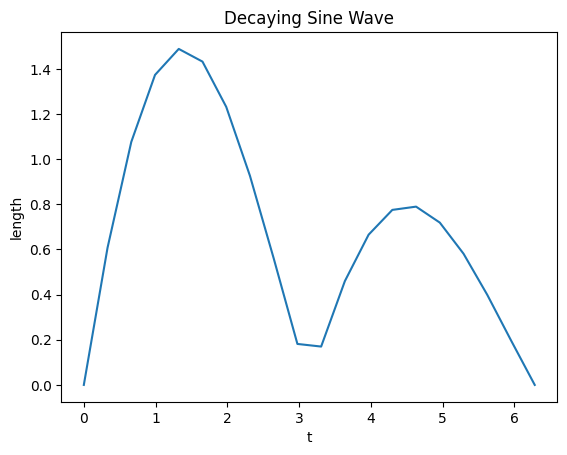

In [5]:
t = np.linspace(0, 2*np.pi, 20) # Initialize t
for i in range (0, 390,30):
  # y = np.sin(w * t + np.deg2rad(i)) # Use np.sin and fix the variable name
  y = np.sin(t) * np.exp(-0.2 * t)

length = 2*abs(y)

fig = plt.figure()
plt.plot(t, length) # Plot the last generated sine wave
plt.xlabel('t')
plt.ylabel('length')
plt.title('Decaying Sine Wave')
plt.show()


In [6]:
t = np.linspace(0,100,3000)

pendlist = [f"pend{i}" for i in range(1, 21)]
xlist    = [f"x{i}" for i in range(1, 21)]
zlist    = [f"z{i}" for i in range(1, 21)]
sollist  = [f"sol{i}" for i in range(1, 21)]

pendlistR = [f"pendR{i}" for i in range(1, 21)]
xlistR    = [f"xR{i}" for i in range(1, 21)]
zlistR    = [f"zR{i}" for i in range(1, 21)]
sollistR  = [f"solR{i}" for i in range(1, 21)]

xa = []
za = []
sola = []

for p, l, x, y, sol in zip (pendlist, length, xlist, zlist, sollist):
  p = Pendulum(l, t, np.pi/6, 0)
  x,z,sol = p.SolvePendulum()
  xa.append(x)
  za.append(z)
  sola.append(sol)

for p, l, x, y, sol in zip (pendlistR, length, xlistR, zlistR, sollistR):
  p = Pendulum(l, t, np.pi*5/6, 0)
  x,z,sol = p.SolvePendulumR()
  xa.append(x)
  za.append(z)
  sola.append(sol)

<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in scalar divide
  return -g*sin(_Dummy_39)/l
/tmp/ipython-input-1927988850.py:50: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  sol = odeint(dXdt, t=t, y0=conds, args=(g,l))
<lambdifygenerated-82>:2: RuntimeWarning: invalid value encountered in scalar divide
  return -g*sin(_Dummy_199)/l
/tmp/ipython-input-1927988850.py:99: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  sol = odeint(dXdt, t=t, y0=conds, args=(g,l))


In [7]:
pendlistR

['pendR1',
 'pendR2',
 'pendR3',
 'pendR4',
 'pendR5',
 'pendR6',
 'pendR7',
 'pendR8',
 'pendR9',
 'pendR10',
 'pendR11',
 'pendR12',
 'pendR13',
 'pendR14',
 'pendR15',
 'pendR16',
 'pendR17',
 'pendR18',
 'pendR19',
 'pendR20']

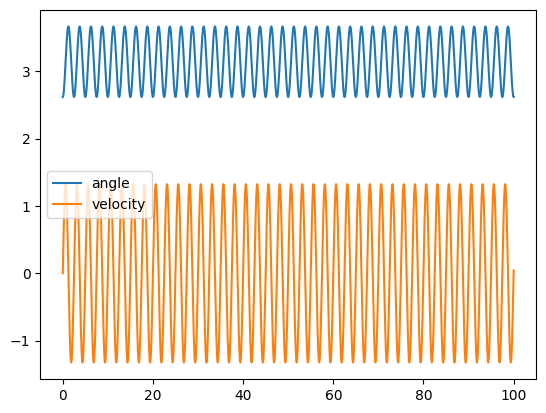

In [8]:
theta = sol.T[0]
velocity = sol.T[1]

plt.plot(t, theta, label ='angle')
plt.plot(t, velocity, label = 'velocity')
plt.legend()


# **Need for loop for the next cell**

In [9]:
# print(type(xa))
# print(len(xa))
# xa[5]

# i2 =  int(len(xa)/2)
# print(i2)

In [10]:
def delayfunc(x, shift):
  xa0 = x[0]
  xatrial = np.roll(x, shift)
  xatrial[:shift] = xa0
  return xatrial

i2 =  int((len(xa))/2)
print(type(i2))

shift = 5

for i in range (0, i2):
  xa[i] = delayfunc(xa[i], shift*i)
  za[i] = delayfunc(za[i], shift*i)

for i in range (0, i2):
  xa[i+i2] = delayfunc(xa[i+i2], shift*i)
  za[i+i2] = delayfunc(za[i+i2], shift*i)


<class 'int'>


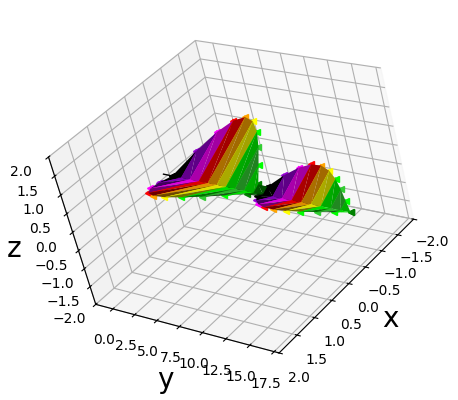

In [11]:
x0list = [xa[i][0] for i in range(40)]
z0list = [za[i][0] for i in range(40)]

Ypoint = [round(num, 2) for num in np.arange(1, 21, 1).tolist()]
Ypoint = Ypoint + Ypoint

colours  = ['black', 'darkviolet', 'magenta', 'red', 'orange', 'yellow', 'lime', 'limegreen', 'lime', 'green', 'black', 'darkviolet', 'magenta', 'red', 'orange', 'yellow', 'lime', 'limegreen', 'lime', 'green', 'black', 'darkviolet', 'magenta', 'red', 'orange', 'yellow', 'lime', 'limegreen', 'lime', 'green', 'black', 'darkviolet', 'magenta', 'red', 'orange', 'yellow', 'lime', 'limegreen', 'lime', 'green' ]

# Store Line2D and Circle objects in
lines = []
bobs = []
bobradius = 0.05
fill = []

import matplotlib as mpl
mpl.rcParams['axes3d.mouserotationstyle'] = 'azel' # 'trackball', 'trackball', 'sphere', or 'arcball'

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.view_init(elev=30, azim=45, roll=15)

ax.set_xlabel('x', fontsize=20)
ax.set_ylabel('y', fontsize=20)
ax.set_zlabel('z', fontsize=20)

line0, = ax.plot([0,0],[0,17], [0,0], lw = 1, c = 'black')

for x0, z0, y0, col in zip(x0list, z0list, Ypoint, colours):
  line, = ax.plot([0,x0],[y0,y0], [0,z0], lw = 2, c = col)
  line.set_3d_properties([0,z0])
  lines.append(line)

  # bob, = ax.plot([x0], [y0], [z0], 'o', color=col, markersize=5)
  bob, = ax.plot([x0], [y0], [z0], '<', color=col, markersize=5)
  bob.set_3d_properties([z0])
  bobs.append(bob)

ax.set_xlim(x.max()-2.0,x.max()+2.0)
ax.set_ylim(-2.0,18.0)
ax.set_zlim(z.min()-2.0, 2.0)

# Create surfaces between consecutive lines
surfaces = []
for i in range(len(lines) - 1):
    # Create a surface object and add it to the plot
    # Plot the surface
    X_surf = np.array([[0, 0], [0, 0]])
    Y_surf = np.array([[Ypoint[i], Ypoint[i]], [Ypoint[i+1], Ypoint[i+1]]])
    Z_surf = np.array([[za[i][0], xa[i][0]], [za[i+1][0], xa[i+1][0]]])
    surf = ax.plot_surface(X_surf, Y_surf, Z_surf, color=colours[i], alpha=0.9)
    surfaces.append(surf)

def animate_with_fill(i):

    # If you need filled areas, it is recommended to create them via plot_trisurf, which creates a triangulation and thus generates consistent surfaces.

    for j in range(len(lines) - 1):
        # Update line data
        lines[j].set_data_3d([0, za[j][i]], [Ypoint[j], Ypoint[j]], [0, xa[j][i]])
        bobs[j].set_data_3d([za[j][i]], [Ypoint[j]], [xa[j][i]])

        # Update surface data
        # Define vertices for the two lines at this frame
        x_verts = np.concatenate(([0, xa[j][i]], [0, xa[j+1][i]]))
        y_verts = np.concatenate(([Ypoint[j], Ypoint[j]], [Ypoint[j+1], Ypoint[j+1]]))
        z_verts = np.concatenate(([0, za[j][i]], [0, za[j+1][i]]))

        # Define triangles for the surface
        triangles = np.array([[0, 1, 2], [1, 2, 3]])

        surfaces[j].remove()  # Remove previous surface
        surf = ax.plot_trisurf(z_verts, y_verts, x_verts, triangles=triangles, color=colours[j], alpha=1.0)
        # surf = ax.plot_trisurf(x_verts, y_verts, z_verts, triangles=triangles, color=colours[j], alpha=0.5)
        surfaces[j] = surf  # Add new surface

    # Update the last line and bob
    lines[-1].set_data_3d([0, za[-1][i]], [Ypoint[-1], Ypoint[-1]], [0, xa[-1][i]])
    bobs[-1].set_data_3d([za[-1][i]], [Ypoint[-1]], [xa[-1][i]])

    return lines + bobs + surfaces

steps = len(xa[0]) # use length of inner array
frames = steps
dt = t[1] - t[0]
interval = dt*10000

ani_fill = animation.FuncAnimation(fig, animate_with_fill, frames=steps, interval=interval, repeat=True)
ffmpeg_writer = animation.FFMpegWriter(fps=50)
ani_fill.save('Pendulum_filled.mp4', writer=ffmpeg_writer)

In [12]:
EndTime = datetime.datetime.now()
print (EndTime)

ElapsedTime = EndTime - InitialTime
print (ElapsedTime)

2026-02-25 13:56:51.822678
0:14:04.352965
